# Jupyter Notebook
# Lec 28 - SVCs

![](https://upload.wikimedia.org/wikipedia/commons/thumb/7/72/SVM_margin.png/300px-SVM_margin.png)

In [30]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import time
import seaborn as sns


# ML imports we've used previously
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



In this module we are going to test out the SVC methods discussed in class. The book's definitions as we talked about in class are:

- *Maximal Margin Classifiers*, where the goal was to find a separating hyperplane with no misclassifications, 
- *Support vector classifiers*, where we allow for a soft margin and hence some data points can end up either on the wrong side of the margin or the wrong side of the hyperplane. 

The `sklearn` function to do this is `SVC`.  This can do either version above as long as we pass the correct inputs to do all of this, and we can basically trick it (by understanding the innards) into doing any of them.  **<font color=red>However, there are two things that will likely be confusing. </font>**
- The command is just called `SVC`, but you should thinking of it as doing the most general SVM as defined in the book (we'll cover this next class) and then we can modify our inputs to allow for the other options as necessary.
- The cost input parameter is **not** the same as the `C` defined in the book but it controls the same thing. 

The code below is to make plotting easier later.  Once you have your $\beta_0$, $\beta_1$, $\beta_2$ you should be able to easily draw the line. 

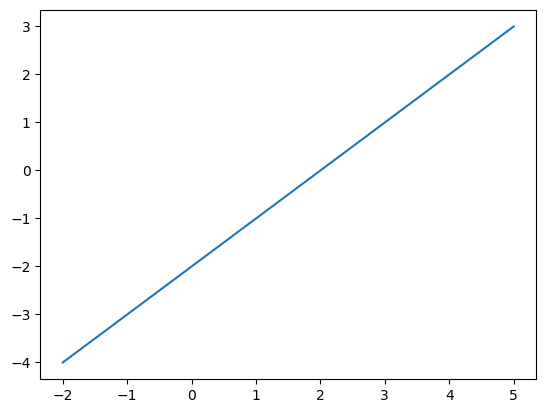

In [31]:
def plotLine(b0,b1,b2,xmin = -2, xmax = 5):
    """
    Pass in your coefficients to draw the line 
    b0 + b1 * X_1 + b2 * X_2 = 0
    """
    a = -b1 / b2
    xx = np.linspace(xmin,xmax)
    yy = a * xx - b0 / b2

    plt.plot(xx,yy)
    

plotLine(b0 = 2, b1 = -1, b2 = 1)
plt.show()

For now, we're going to mess with some synthetic data (meaning I generated it and saved it as a CSV for you). 

In [32]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/79b8d68a386530ebf693a9130c756277/SVM-Data.csv"
data_df = pd.read_csv(url, 
                delimiter=' ', 
                header = None, 
                )

data_df.columns = ['X1','X2', 'y']
data_df.head(10)

,X1,X2,y
0,0.996440,0.712421,1.0
1,1.422487,3.152205,-1.0
2,0.059144,-0.363311,1.0
3,0.100738,0.355438,1.0
4,1.406597,2.788238,-1.0
5,-0.336336,-0.100614,1.0
6,-0.052308,0.249218,1.0
7,2.568133,2.012758,-1.0
8,1.564296,2.972179,-1.0
9,0.187603,-0.329870,1.0


Here's a few helpful subsets of the data we can use for later drawing depending on what we want to do with it. 

In [33]:
# Just the X and y as numpy arrays
X = data_df[['X1','X2']].values 
y = data_df['y'].values

# Just the data points where the y value is 1
X_pos = X[y>0]

# Just the data points where the y value is -1
X_neg = X[y<0]


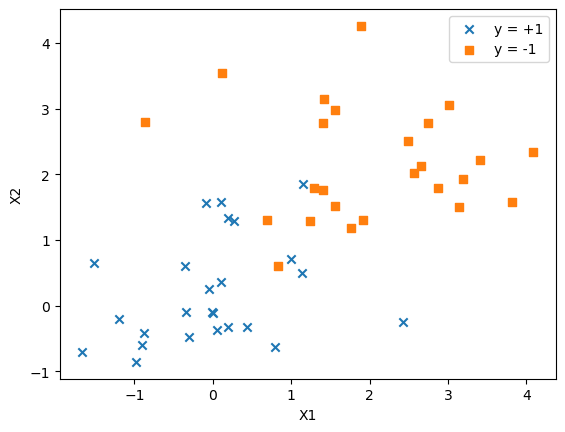

In [34]:
# Plotting so that we can see which points have y=+1 and which have y = -1
plt.scatter(X_pos[:,0], X_pos[:,1], label = 'y = +1', marker = 'x')
plt.scatter(X_neg[:,0], X_neg[:,1], label = 'y = -1', marker = 's')
plt.legend()
plt.xlabel('X1')
plt.ylabel('X2')

plt.show()

And then, tada! Here's all it takes to fit your support vector classifier. 

In [35]:
from sklearn.svm import SVC

In [36]:
svc = SVC(C=1, kernel='linear', )
svc.fit(X,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


&#9989; **<font color=red>Do this:</font>** Use your trained model to figure out the equation of the hyperplane (hint: go looking for the `coef_` and `intercept_`). 

In [37]:
# Your code here 


&#9989; **<font color=red>Do this:</font>** Based on the above trained model, plot it on a graph with the data points (see above for the `plotLine` function!).  Does the resulting hyperplane seem reasonable? 

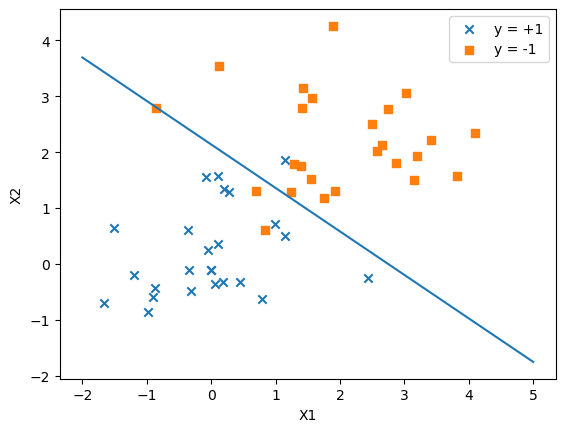

In [11]:
plt.scatter(X_pos[:,0], X_pos[:,1], label = 'y = +1', marker = 'x')
plt.scatter(X_neg[:,0], X_neg[:,1], label = 'y = -1', marker = 's')
plt.legend()
plt.xlabel('X1')
plt.ylabel('X2')

plotLine(b0,b1,b2)


# Your code here to also plot the support vectors, stored above as `sv`


plt.show()

Remember that the SVC setting only uses a subset of observations, called *support vectors* to actually determine this hyperplane. The `svc` object keeps track of those for us. 

In [13]:
# Here are the indices of the support vectors from our original X matrix

svc.support_

array([18, 22, 32, 33, 39, 42, 44,  0, 21, 27, 30, 31, 40, 47],
      dtype=int32)

In [14]:
# It also keeps track of the points themselves 
sv = svc.support_vectors_
print(sv)

[[-0.85968797  2.7893664 ]
 [ 1.28953355  1.7848122 ]
 [ 1.23923969  1.28883677]
 [ 0.83529809  0.60292598]
 [ 1.55457001  1.51787981]
 [ 0.68922687  1.31043477]
 [ 1.75928886  1.17587655]
 [ 0.99643983  0.71242127]
 [ 2.43077119 -0.25209213]
 [ 0.19766009  1.33484857]
 [ 0.26961241  1.29196338]
 [ 0.10960984  1.58248112]
 [-0.08687561  1.56153229]
 [ 1.15139101  1.85733101]]


&#9989; **<font color=red>Do this:</font>** Draw a scatter plot of these points on top of the drawing you've already been building with some different marker.  Do these points make sense to be the support vectors?



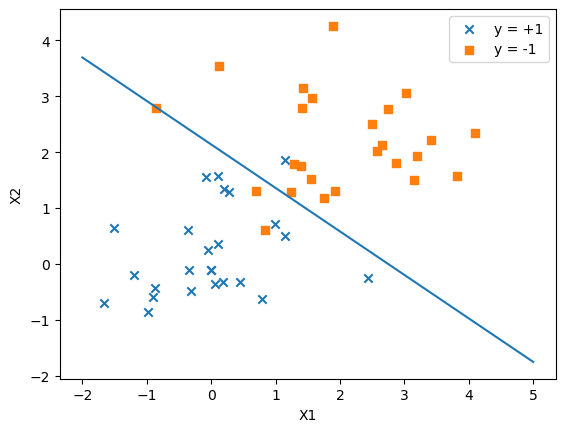

In [15]:
plt.scatter(X_pos[:,0], X_pos[:,1], label = 'y = +1', marker = 'x')
plt.scatter(X_neg[:,0], X_neg[:,1], label = 'y = -1', marker = 's')
plt.legend()
plt.xlabel('X1')
plt.ylabel('X2')

plotLine(b0,b1,b2)


# Your code here to also plot the support vectors, stored above as `sv`


plt.show()

Now that you have a sense of what's going on in the svc function, I've built you a function that will make this nice drawing for us without much effort.  We can hand it our `X` and `y` data, along with the trained `svc` to get the plot, with some added stuff, including dashed lines for the margin and colors for which side of the hyperplane you're on (blue for -1, red for +1).

In [17]:
# Run this cell to define the function
def plot_svc(svc, X, y, h=0.02, pad=0.25):
    x_min, x_max = X[:, 0].min()-pad, X[:, 0].max()+pad
    y_min, y_max = X[:, 1].min()-pad, X[:, 1].max()+pad
    xvec = np.arange(x_min, x_max, h)
    yvec = np.arange(y_min, y_max, h)
    xx, yy = np.meshgrid(xvec,yvec )
    
    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.2)

    plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=mpl.cm.Paired)
    # Support vectors indicated in plot by X's
    sv = svc.support_vectors_
    plt.scatter(sv[:,0], sv[:,1], c='k', marker='x', s=100, linewidths=1)
    
    if svc.kernel == 'linear':
        # Get the margin lines 
        w = svc.coef_[0]
        a = -w[0] / w[1]
        yhyperplane = a * xvec - (svc.intercept_[0]) / w[1]
        margin = 1 / np.sqrt(np.sum(svc.coef_ ** 2))
        ymargin_down = yhyperplane+  - np.sqrt(1 + a ** 2) * margin
        ymargin_up = yhyperplane + np.sqrt(1 + a ** 2) * margin
        plt.plot(xvec,ymargin_down, "k--")
        plt.plot(xvec,ymargin_up, "k--")

    
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('X1')
    plt.ylabel('X2')
    # plt.show()
    print('Number of support vectors: ', svc.support_.size)



Number of support vectors:  14


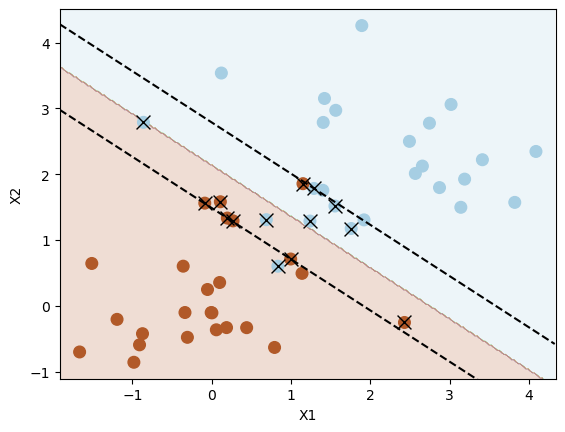

In [18]:
#From here on, you can just use this command to plot.
# I'm passing in the trained SVC classifier, plus the X and y data used
plot_svc(svc, X, y)

plt.show()


## Messing with $C$


As in class, the `C` parameter controls how severe the margin violations can be. However, there is a warning: 

**WARNING**: 
The $C$ in the class/textbook and the $C$ used as input to the `SVC` command are **NOT THE SAME**.
- The cost $C$ in class had the property that big $C$ meant big margin 
- This is a DIFFERENT $C$. In this case, big $C$ means small margin. 

They're both serving the same purpose, i.e. to control how tolerant we are to misclassifications. 

Let's take a look at a few examples in here.

Number of support vectors:  21


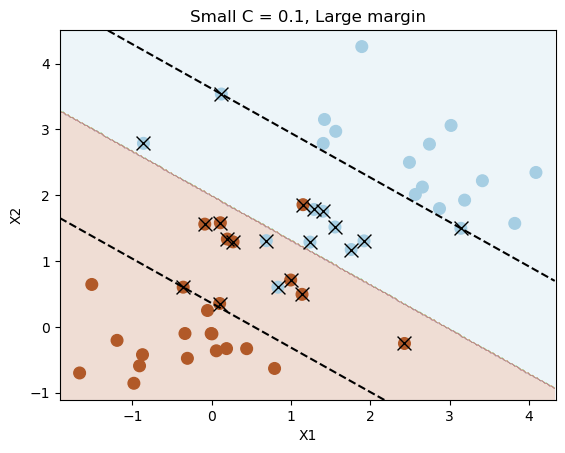

In [19]:
svc = SVC(C=10e-2, kernel='linear', )
svc.fit(X, y)
plot_svc(svc, X, y)

plt.title(f"Small C = {10e-2}, Large margin")
plt.show()

Number of support vectors:  14


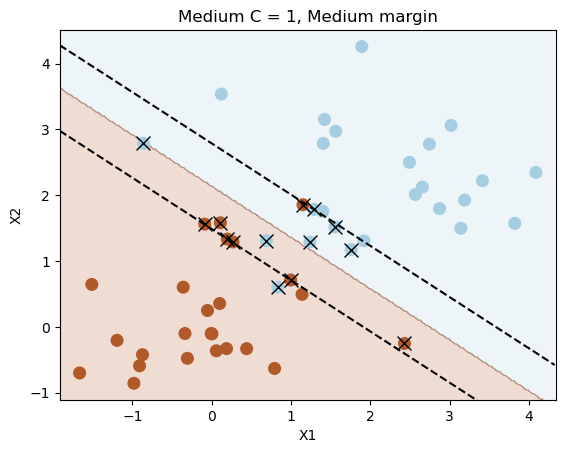

In [20]:
svc = SVC(C=1, kernel='linear', )
svc.fit(X, y)
plot_svc(svc, X, y)

plt.title(f"Medium C = 1, Medium margin")
plt.show()

Number of support vectors:  9


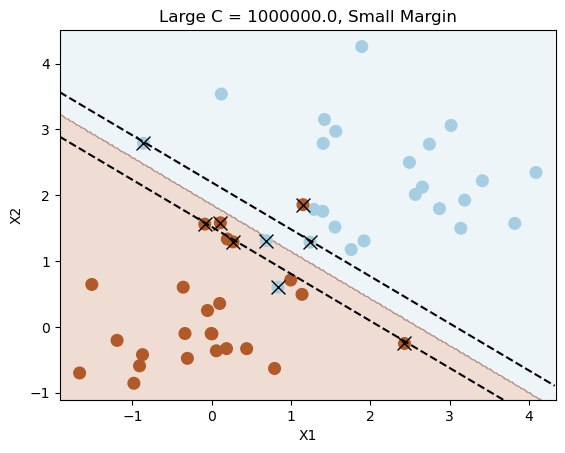

In [21]:
svc = SVC(C=10e5, kernel='linear', )
svc.fit(X, y)
plot_svc(svc, X, y)

plt.title(f"Large C = {10e5}, Small Margin")
plt.show()


As with previous examples in this class, we can use K-Fold CV to tune this parameter. 

In [22]:
from sklearn.model_selection import GridSearchCV

In [23]:
# Select the optimal C parameter by cross-validation
C_list = [0.001, 0.01, 0.1, 1, 5, 10, 100]
tuned_parameters = [{'C': C_list}]
clf = GridSearchCV(SVC(kernel='linear'), tuned_parameters, cv=10, scoring='accuracy')
clf.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='linear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.001, 0.01, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramete

&#9989; **<font color=red>Do this:</font>** Use the `clf.cv_results_` function to determine which $C$ give the best score (note there could be ties). Which $C$ did the function choose? 

In [24]:
# Your code here

&#9989; **<font color=red>Do this:</font>** Load in the `SVM-Data2.csv` data from the folder. Run this same analysis again, namely: 
- Use the `GridSearchCV` function to determine the best choice of $C$.


In [26]:
###YOUR CODE HERE###

&#9989; **<font color=red>Do this:</font>** 
- Train an individual `SVC` instance with $C$ set to that value.  Then you can draw the resulting model with the `plot_svc` function from earlier. How does the model do?

In [28]:
###YOUR CODE HERE###



-----
### Congratulations, we're done!
Initially created by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh,  Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.